# Bab 5 — Learning Multiple Weights at a Time: Generalizing Gradient Descent

Notebook ini merangkum **Bab 5** buku *Grokking Deep Learning* (Andrew W. Trask, 2019).

Bab 4 melatih **satu bobot**. Bab ini menggeneralisasi gradient descent untuk **banyak bobot sekaligus** — banyak input, banyak output, dan keduanya — lalu melihat **apa yang sebenarnya dipelajari** oleh bobot-bobot tersebut pada dataset gambar angka tulisan tangan (MNIST).

Isi notebook:
1. Gradient descent dengan multiple inputs
2. Penjelasan: satu delta, banyak weight_delta
3. Mengamati beberapa langkah learning (& pentingnya skala input)
4. Membekukan satu bobot (*freezing*): apa efeknya?
5. Gradient descent dengan multiple outputs
6. Gradient descent dengan multiple inputs & outputs
7. Apa yang dipelajari bobot? — MNIST
8. Memvisualisasikan nilai bobot
9. Memvisualisasikan dot product (weighted sum)

## 0. Setup

In [1]:
from pathlib import Path
import urllib.request

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
np.random.seed(1)

DATA_DIR = Path('data')
BOOK_URL = 'https://raw.githubusercontent.com/iamtrask/Grokking-Deep-Learning/master/'

def fetch(name, url=None):
    """Kembalikan path file di data/; unduh dulu kalau belum ada."""
    DATA_DIR.mkdir(exist_ok=True)
    local = DATA_DIR / name
    if not local.exists():
        urllib.request.urlretrieve(url or BOOK_URL + name, local)
    return local

def load_mnist():
    """MNIST (60k train, 10k test) dari mirror resmi Keras -> array NumPy."""
    path = fetch('mnist.npz', 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz')
    with np.load(path) as f:
        return (f['x_train'], f['y_train']), (f['x_test'], f['y_test'])

## 1. Gradient Descent dengan Multiple Inputs

Network multiple inputs dari Bab 3 (3 input → 1 output). Kuncinya: **semua bobot berbagi satu `delta` yang sama** (karena hanya ada satu output), tetapi setiap bobot mendapat `weight_delta` sendiri dengan mengalikan `delta` dengan **input-nya masing-masing**:

$$\delta = \hat{y} - y, \qquad \Delta w_i = \delta \cdot x_i, \qquad w_i \leftarrow w_i - \alpha\,\Delta w_i$$

In [2]:
def w_sum(a, b):
    assert len(a) == len(b)
    output = 0
    for i in range(len(a)):
        output += a[i] * b[i]
    return output

def ele_mul(number, vector):
    output = [0, 0, 0]
    assert len(output) == len(vector)
    for i in range(len(vector)):
        output[i] = number * vector[i]
    return output

def neural_network(input, weights):
    return w_sum(input, weights)

toes  = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]
win_or_lose_binary = [1, 1, 0, 1]

true = win_or_lose_binary[0]
weights = [0.1, 0.2, -0.1]
alpha = 0.01
input = [toes[0], wlrec[0], nfans[0]]

pred = neural_network(input, weights)        # predict
error = (pred - true) ** 2                   # compare
delta = pred - true
weight_deltas = ele_mul(delta, input)        # learn
for i in range(len(weights)):
    weights[i] -= alpha * weight_deltas[i]

print('Pred :', round(pred, 4), '| Error:', round(error, 4), '| Delta:', round(delta, 4))
print('Weight deltas:', np.round(weight_deltas, 4))
print('Weights baru :', np.round(weights, 4))

Pred : 0.86 | Error: 0.0196 | Delta: -0.14
Weight deltas: [-1.19  -0.091 -0.168]
Weights baru : [ 0.1119  0.2009 -0.0983]


## 2. Penjelasan: Satu Delta, Banyak Weight Delta

| Langkah | Single input (Bab 4) | Multiple inputs |
|---|---|---|
| Predict | `pred = input * weight` | `pred = w_sum(input, weights)` |
| Compare | `delta = pred - true` | `delta = pred - true` (**sama**) |
| Learn | `weight_delta = delta * input` | `weight_deltas = ele_mul(delta, input)` |

**Delta** adalah ukuran seberapa besar kita ingin **nilai node** (prediksi) berubah. **Weight delta** adalah estimasi arah & besar perubahan untuk **bobot** tertentu, yaitu delta dikalikan input bobot tersebut. Efek *stopping*, *negative reversal*, dan *scaling* dari Bab 4 berlaku untuk setiap bobot secara terpisah.

## 3. Mengamati Beberapa Langkah Learning

Perhatikan: `toes` (≈ 8.5) jauh lebih besar daripada `wlrec` (≈ 0.65), sehingga **weight_delta untuk toes jauh lebih besar**. Bobot dengan input besar mendominasi penurunan error.

In [3]:
weights = [0.1, 0.2, -0.1]
alpha = 0.01

for iter in range(3):
    pred = neural_network(input, weights)
    error = (pred - true) ** 2
    delta = pred - true
    weight_deltas = ele_mul(delta, input)
    print(f'Iterasi {iter + 1}: pred={pred:.4f} error={error:.4f} weights={np.round(weights, 4)} '
          f'weight_deltas={np.round(weight_deltas, 4)}')
    for i in range(len(weights)):
        weights[i] -= alpha * weight_deltas[i]

Iterasi 1: pred=0.8600 error=0.0196 weights=[ 0.1  0.2 -0.1] weight_deltas=[-1.19  -0.091 -0.168]
Iterasi 2: pred=0.9638 error=0.0013 weights=[ 0.1119  0.2009 -0.0983] weight_deltas=[-0.3081 -0.0236 -0.0435]
Iterasi 3: pred=0.9906 error=0.0001 weights=[ 0.115   0.2011 -0.0979] weight_deltas=[-0.0797 -0.0061 -0.0113]


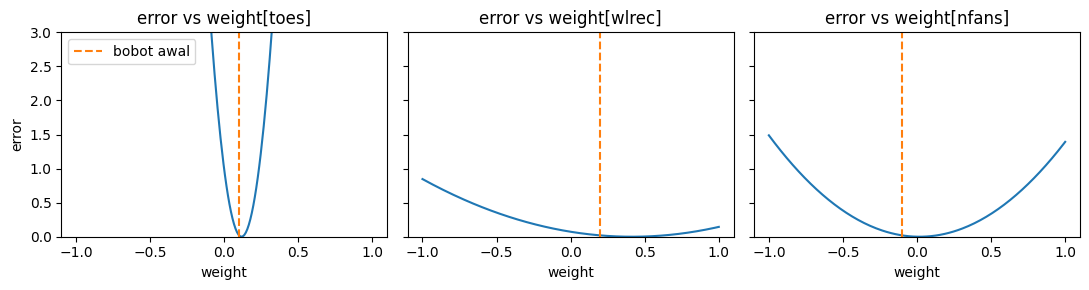

In [4]:
# Kurva error terhadap masing-masing bobot (bobot lain ditahan di nilai awal)
w0 = np.array([0.1, 0.2, -0.1])
x = np.array(input)
grid = np.linspace(-1, 1, 200)

fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for i, name in enumerate(['toes', 'wlrec', 'nfans']):
    errs = []
    for g in grid:
        w = w0.copy(); w[i] = g
        errs.append((x.dot(w) - true) ** 2)
    axes[i].plot(grid, errs)
    axes[i].axvline(w0[i], color='C1', ls='--', label='bobot awal')
    axes[i].set_title(f'error vs weight[{name}]')
    axes[i].set_xlabel('weight')
axes[0].set_ylabel('error'); axes[0].legend()
plt.ylim(0, 3); plt.tight_layout(); plt.show()

Kurva untuk `toes` jauh lebih **curam** — slope curam menghasilkan derivative besar. Kurva `wlrec` dan `nfans` hampir datar, sehingga bobotnya hanya bergeser sedikit.

### Melatih pada keempat pertandingan & pentingnya skala input
Mari latih pada **seluruh dataset** dan bandingkan input mentah dengan input yang sudah **dinormalisasi** (setiap kolom diskalakan ke rata-rata 0 dan standar deviasi 1). Dengan skala yang sama, semua bobot belajar dengan kecepatan yang seimbang dan alpha bisa lebih besar.

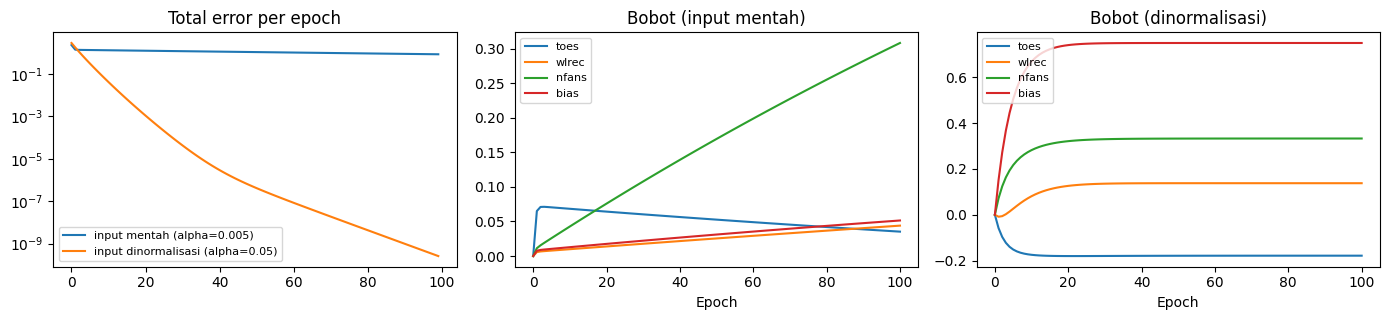

Prediksi akhir (mentah)        : [0.75  0.823 0.59  0.717]
Prediksi akhir (dinormalisasi) : [1. 1. 0. 1.] | target: [1. 1. 0. 1.]


In [5]:
X_raw = np.array([toes, wlrec, nfans]).T              # (4 game, 3 input)
y = np.array(win_or_lose_binary, dtype=float)
X_norm = (X_raw - X_raw.mean(0)) / X_raw.std(0)

# Tambahkan input "bias" yang selalu bernilai 1 (seperti lampu yang selalu menyala di Bab 6)
# agar model bisa menggeser prediksinya; tanpa ini data ternormalisasi (rata-rata 0) sulit di-fit
ones = np.ones((len(y), 1))
X_raw = np.hstack([X_raw, ones])
X_norm = np.hstack([X_norm, ones])

def train_multi(X, y, alpha, iters=100):
    w = np.zeros(X.shape[1])
    errs, ws = [], [w.copy()]
    for _ in range(iters):
        total = 0
        for x_, t in zip(X, y):
            pred = x_.dot(w)
            delta = pred - t
            total += delta ** 2
            w -= alpha * delta * x_
        errs.append(total)
        ws.append(w.copy())
    return np.array(errs), np.array(ws)

errs_raw, ws_raw = train_multi(X_raw, y, alpha=0.005)
errs_norm, ws_norm = train_multi(X_norm, y, alpha=0.05)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.3))
axes[0].plot(errs_raw, label='input mentah (alpha=0.005)')
axes[0].plot(errs_norm, label='input dinormalisasi (alpha=0.05)')
axes[0].set_yscale('log'); axes[0].set_title('Total error per epoch'); axes[0].legend(fontsize=8)
for ax, ws, title in [(axes[1], ws_raw, 'Bobot (input mentah)'), (axes[2], ws_norm, 'Bobot (dinormalisasi)')]:
    for i, n in enumerate(['toes', 'wlrec', 'nfans', 'bias']):
        ax.plot(ws[:, i], label=n)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('Prediksi akhir (mentah)        :', X_raw.dot(ws_raw[-1]).round(3))
print('Prediksi akhir (dinormalisasi) :', X_norm.dot(ws_norm[-1]).round(3), '| target:', y)

Dengan input mentah, bobot `toes` mendominasi sementara bobot lain nyaris tidak bergerak, dan alpha harus kecil agar tidak divergen. Setelah dinormalisasi, semua bobot belajar seimbang, alpha bisa 10× lebih besar, dan error turun jauh lebih cepat.

## 4. Membekukan Satu Bobot: Apa Efeknya?

Eksperimen dari buku: bagaimana jika `weight_deltas[0]` (bobot `toes`) **selalu dibuat 0**? Ternyata network **tetap** bisa mencapai error ≈ 0 karena bobot lain mengompensasi.

In [6]:
weights = [0.1, 0.2, -0.1]
alpha = 0.3
input = [toes[0], wlrec[0], nfans[0]]
freeze_hist = [list(weights)]

for iter in range(3):
    pred = neural_network(input, weights)
    error = (pred - true) ** 2
    delta = pred - true
    weight_deltas = ele_mul(delta, input)
    weight_deltas[0] = 0          # bekukan bobot toes
    print(f'Iterasi {iter + 1}: pred={pred:.4f} error={error:.6f} weights={np.round(weights, 4)}')
    for i in range(len(weights)):
        weights[i] -= alpha * weight_deltas[i]
    freeze_hist.append(list(weights))

Iterasi 1: pred=0.8600 error=0.019600 weights=[ 0.1  0.2 -0.1]
Iterasi 2: pred=0.9382 error=0.003816 weights=[ 0.1     0.2273 -0.0496]
Iterasi 3: pred=0.9727 error=0.000743 weights=[ 0.1     0.2393 -0.0274]


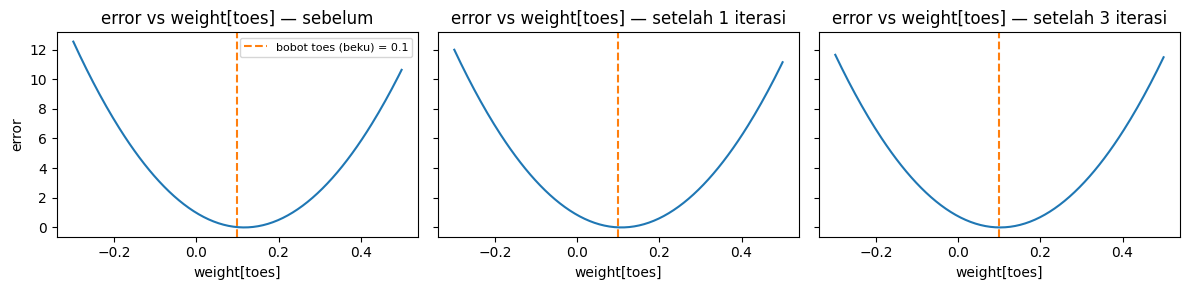

In [7]:
# Kurva error untuk bobot toes (yang dibekukan) sebelum & sesudah bobot lain belajar
grid = np.linspace(-0.3, 0.5, 200)
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, (label, w_state) in zip(axes, [('sebelum', freeze_hist[0]), ('setelah 1 iterasi', freeze_hist[1]),
                                       ('setelah 3 iterasi', freeze_hist[3])]):
    errs = [(np.array([g, w_state[1], w_state[2]]).dot(x) - true) ** 2 for g in grid]
    ax.plot(grid, errs)
    ax.axvline(0.1, color='C1', ls='--', label='bobot toes (beku) = 0.1')
    ax.set_title(f'error vs weight[toes] — {label}'); ax.set_xlabel('weight[toes]')
axes[0].legend(fontsize=8); axes[0].set_ylabel('error')
plt.tight_layout(); plt.show()

Pelajaran penting dari buku:
- Bobot `toes` tidak pernah bergerak, tetapi **kurva errornya bergeser** sehingga dasar mangkuk kini berada tepat di posisinya — karena bobot lain (`wlrec`, `nfans`) berubah.
- **Error ditentukan bersama oleh semua bobot.** Kurva error setiap bobot bergantung pada nilai bobot lainnya.
- Begitu error = 0, network **berhenti belajar**. Ini bisa berbahaya: network mungkin mengabaikan input yang sebenarnya sangat prediktif (di sini `toes`) hanya karena input lain sudah cukup untuk dataset training. Ini cikal bakal masalah *overfitting* (Bab 6 & 8).

## 5. Gradient Descent dengan Multiple Outputs

Sekarang **satu input → banyak output** (`wlrec` → hurt?, win?, sad?). Setiap output punya `delta` sendiri, dan setiap bobot hanya terhubung ke satu output:

$$\delta_j = \hat{y}_j - y_j, \qquad \Delta w_j = x \cdot \delta_j$$

In [8]:
def scalar_ele_mul(number, vector):
    return [number * v for v in vector]

weights = [0.3, 0.2, 0.9]   # hurt?, win?, sad?

def neural_network(input, weights):
    return scalar_ele_mul(input, weights)

wlrec = [0.65, 1.0, 1.0, 0.9]
hurt  = [0.1, 0.0, 0.0, 0.1]
win   = [1, 1, 0, 1]
sad   = [0.1, 0.0, 0.1, 0.2]

input = wlrec[0]
true = [hurt[0], win[0], sad[0]]
alpha = 0.1

pred = neural_network(input, weights)
error = [(p - t) ** 2 for p, t in zip(pred, true)]
delta = [p - t for p, t in zip(pred, true)]
weight_deltas = scalar_ele_mul(input, delta)
weights = [w - alpha * wd for w, wd in zip(weights, weight_deltas)]

print('Pred    :', np.round(pred, 4))
print('Error   :', np.round(error, 4))
print('Delta   :', np.round(delta, 4))
print('Weights :', np.round(weights, 4))

Pred    : [0.195 0.13  0.585]
Error   : [0.009  0.7569 0.2352]
Delta   : [ 0.095 -0.87   0.485]
Weights : [0.2938 0.2566 0.8685]


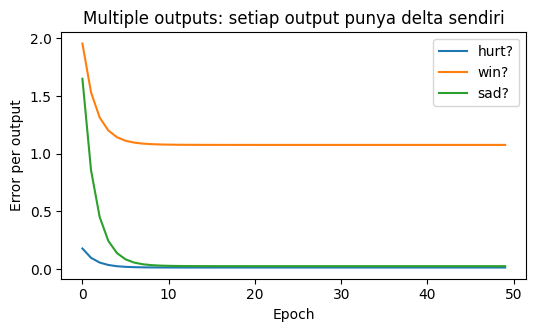

Bobot akhir (hurt?, win?, sad?): [0.048 0.77  0.112]


In [9]:
# Latih untuk keempat contoh: setiap output belajar secara independen
weights = np.array([0.3, 0.2, 0.9])
X1 = np.array(wlrec)
Y3 = np.array([hurt, win, sad]).T
err_hist = []
for epoch in range(50):
    e = np.zeros(3)
    for x_, t in zip(X1, Y3):
        pred = x_ * weights
        e += (pred - t) ** 2
        weights -= alpha * x_ * (pred - t)
    err_hist.append(e)
err_hist = np.array(err_hist)

plt.figure(figsize=(6, 3.2))
for k, n in enumerate(['hurt?', 'win?', 'sad?']):
    plt.plot(err_hist[:, k], label=n)
plt.xlabel('Epoch'); plt.ylabel('Error per output'); plt.legend()
plt.title('Multiple outputs: setiap output punya delta sendiri')
plt.show()
print('Bobot akhir (hurt?, win?, sad?):', weights.round(3))

Error `win?` tidak turun ke 0 karena satu input (`wlrec`) tidak cukup untuk menjelaskan semua hasil (game ketiga kalah meskipun `wlrec = 1.0`). Network menemukan kompromi terbaik.

## 6. Gradient Descent dengan Multiple Inputs & Outputs

Gabungan keduanya: **3 input → 3 output** dengan matriks bobot 3×3. `weight_deltas` adalah **outer product** antara vektor `delta` (output) dan vektor `input`:

$$\Delta W_{ji} = \delta_j \cdot x_i \quad\Longleftrightarrow\quad \Delta W = \boldsymbol{\delta} \otimes \mathbf{x}$$

Setiap bobot `W[j][i]` menghubungkan input `i` ke output `j`, sehingga weight_delta-nya adalah delta output `j` × input `i`.

In [10]:
def outer_prod(vec_a, vec_b):
    out = np.zeros((len(vec_a), len(vec_b)))
    for i in range(len(vec_a)):
        for j in range(len(vec_b)):
            out[i][j] = vec_a[i] * vec_b[j]
    return out

            # toes %win #fans
weights = np.array([[0.1, 0.1, -0.3],   # hurt?
                    [0.1, 0.2,  0.0],   # win?
                    [0.0, 1.3,  0.1]])  # sad?

def neural_network(input, weights):
    return weights.dot(input)

toes  = np.array([8.5, 9.5, 9.9, 9.0])
wlrec = np.array([0.65, 0.8, 0.8, 0.9])
nfans = np.array([1.2, 1.3, 0.5, 1.0])
hurt  = np.array([0.1, 0.0, 0.0, 0.1])
win   = np.array([1, 1, 0, 1])
sad   = np.array([0.1, 0.0, 0.1, 0.2])

alpha = 0.01
input = np.array([toes[0], wlrec[0], nfans[0]])
true = np.array([hurt[0], win[0], sad[0]])

pred = neural_network(input, weights)
error = (pred - true) ** 2
delta = pred - true
weight_deltas = outer_prod(delta, input)
print('Loop outer_prod sama dengan np.outer?', np.allclose(weight_deltas, np.outer(delta, input)))
weights -= alpha * weight_deltas

print('Pred  :', pred.round(4))
print('Error :', error.round(4))
print('Weight deltas:\n', weight_deltas.round(4))

Loop outer_prod sama dengan np.outer? True
Pred  : [0.555 0.98  0.965]
Error : [2.070e-01 4.000e-04 7.482e-01]
Weight deltas:
 [[ 3.8675  0.2958  0.546 ]
 [-0.17   -0.013  -0.024 ]
 [ 7.3525  0.5623  1.038 ]]


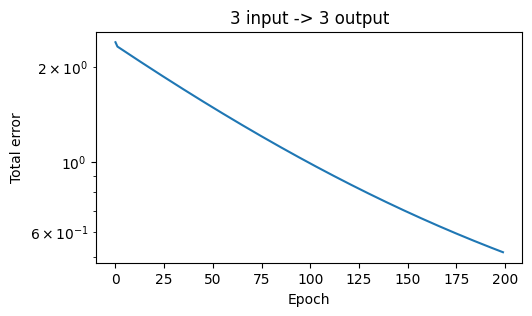

Prediksi akhir:
 [[ 0.02  0.98 -0.06]
 [ 0.03  1.09  0.02]
 [ 0.12  0.46  0.04]
 [ 0.08  0.91  0.21]]
Target:
 [[0.1 1.  0.1]
 [0.  1.  0. ]
 [0.  0.  0.1]
 [0.1 1.  0.2]]


In [11]:
# Latih untuk ke-4 contoh selama beberapa epoch
X = np.stack([toes, wlrec, nfans], axis=1)
Y = np.stack([hurt, win, sad], axis=1)
losses = []
for epoch in range(200):
    total = 0
    for x_, t in zip(X, Y):
        pred = weights.dot(x_)
        delta = pred - t
        total += (delta ** 2).sum()
        weights -= alpha * np.outer(delta, x_)
    losses.append(total)

plt.figure(figsize=(5.5, 3))
plt.plot(losses); plt.yscale('log')
plt.xlabel('Epoch'); plt.ylabel('Total error'); plt.title('3 input -> 3 output')
plt.show()
print('Prediksi akhir:\n', X.dot(weights.T).round(2))
print('Target:\n', Y)

## 7. Apa yang Dipelajari Bobot? — MNIST

**MNIST** adalah dataset 70.000 gambar angka tulisan tangan 0–9 berukuran 28×28 piksel (dikumpulkan oleh NIST, dipopulerkan oleh Yann LeCun). Setiap gambar diratakan (*flatten*) menjadi **784 input**, dan network memiliki **10 output** (satu per angka). Ini persis network multiple inputs & outputs di atas, hanya lebih besar: matriks bobot **784 × 10**.

Label diubah menjadi **one-hot**: angka 3 → `[0,0,0,1,0,0,0,0,0,0]`, sehingga setiap output memprediksi "apakah gambar ini angka *k*?".

Train: (60000, 28, 28) | Test: (10000, 28, 28)
Nilai piksel: min 0 max 255


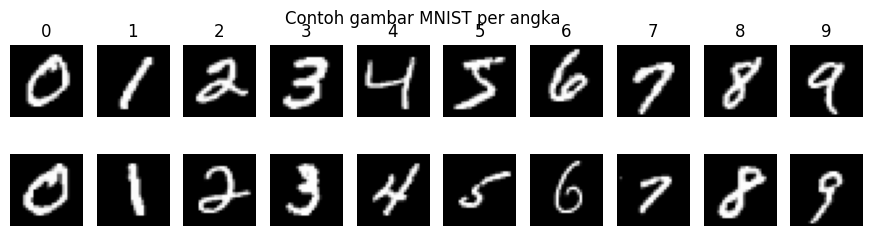

In [12]:
(x_train, y_train), (x_test, y_test) = load_mnist()
print('Train:', x_train.shape, '| Test:', x_test.shape)
print('Nilai piksel: min', x_train.min(), 'max', x_train.max())

fig, axes = plt.subplots(2, 10, figsize=(11, 2.6))
for d in range(10):
    for r in range(2):
        idx = np.where(y_train == d)[0][r]
        axes[r, d].imshow(x_train[idx], cmap='gray'); axes[r, d].axis('off')
    axes[0, d].set_title(d)
plt.suptitle('Contoh gambar MNIST per angka')
plt.show()

In [13]:
# Pakai 1000 gambar pertama seperti di buku; skala piksel ke 0..1 dan label one-hot
images = x_train[:1000].reshape(1000, 28 * 28) / 255
labels = np.eye(10)[y_train[:1000]]
test_images = x_test.reshape(len(x_test), 28 * 28) / 255
print('images:', images.shape, '| labels:', labels.shape)
print('label one-hot gambar pertama:', labels[0], '-> angka', y_train[0])

np.random.seed(1)
W = 0.02 * np.random.random((784, 10)) - 0.01
alpha = 0.005
hist = []

for epoch in range(30):
    error = 0
    for x_, t in zip(images, labels):
        pred = x_.dot(W)
        delta = pred - t
        error += (delta ** 2).sum()
        W -= alpha * np.outer(x_, delta)
    train_acc = (images.dot(W).argmax(1) == y_train[:1000]).mean()
    test_acc = (test_images.dot(W).argmax(1) == y_test).mean()
    hist.append((error / 1000, train_acc, test_acc))
    if epoch % 5 == 0 or epoch == 29:
        print(f'Epoch {epoch:2d}  Error: {error / 1000:.3f}  Train acc: {train_acc:.3f}  Test acc: {test_acc:.3f}')

images: (1000, 784) | labels: (1000, 10)
label one-hot gambar pertama: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.] -> angka 5
Epoch  0  Error: 0.553  Train acc: 0.841  Test acc: 0.758


Epoch  5  Error: 0.379  Train acc: 0.906  Test acc: 0.774


Epoch 10  Error: 0.344  Train acc: 0.930  Test acc: 0.765


Epoch 15  Error: 0.323  Train acc: 0.942  Test acc: 0.760


Epoch 20  Error: 0.310  Train acc: 0.950  Test acc: 0.754


Epoch 25  Error: 0.299  Train acc: 0.956  Test acc: 0.749
Epoch 29  Error: 0.293  Train acc: 0.962  Test acc: 0.745


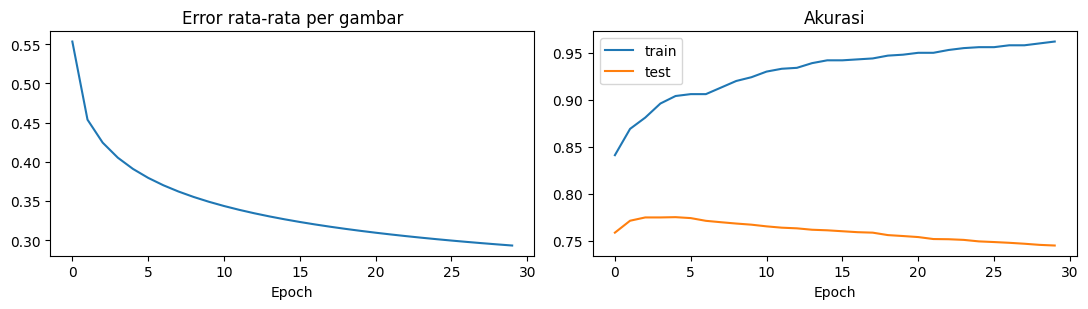

In [14]:
hist = np.array(hist)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(hist[:, 0]); axes[0].set_title('Error rata-rata per gambar'); axes[0].set_xlabel('Epoch')
axes[1].plot(hist[:, 1], label='train'); axes[1].plot(hist[:, 2], label='test')
axes[1].set_title('Akurasi'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

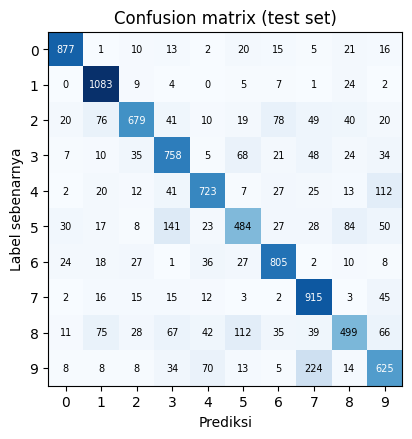

Kesalahan terbanyak: angka 9 diprediksi sebagai 7 (224 kali)


In [15]:
# Confusion matrix pada test set: angka apa yang sering tertukar?
pred_test = test_images.dot(W).argmax(1)
cm = np.zeros((10, 10), dtype=int)
for t, p in zip(y_test, pred_test):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(5.5, 4.6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('Prediksi'); ax.set_ylabel('Label sebenarnya')
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=7,
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.title('Confusion matrix (test set)')
plt.show()

off = cm.copy(); np.fill_diagonal(off, 0)
i, j = np.unravel_index(off.argmax(), off.shape)
print(f'Kesalahan terbanyak: angka {i} diprediksi sebagai {j} ({off[i, j]} kali)')

## 8. Memvisualisasikan Nilai Bobot

Setiap kolom matriks bobot (784 nilai) bisa di-reshape kembali menjadi gambar 28×28. Hasilnya menunjukkan **piksel mana yang berkorelasi** dengan setiap angka: merah = bobot positif (piksel ini menaikkan skor angka tersebut), biru = negatif (piksel ini menurunkan skor).

Menurut Trask, setiap gambar bobot adalah semacam "**template**" kasar dari angka tersebut — network belajar korelasi antara piksel input dan setiap label.

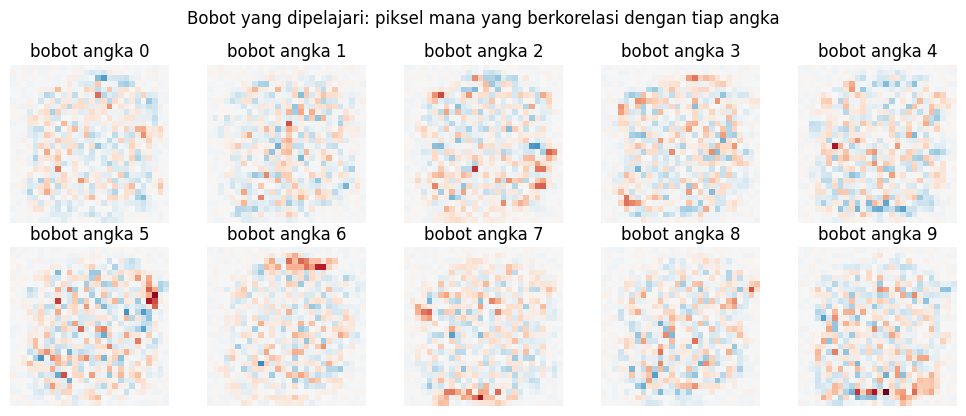

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.2))
lim = np.abs(W).max()
for d, ax in enumerate(axes.flat):
    ax.imshow(W[:, d].reshape(28, 28), cmap='RdBu_r', vmin=-lim, vmax=lim)
    ax.set_title(f'bobot angka {d}'); ax.axis('off')
plt.suptitle('Bobot yang dipelajari: piksel mana yang berkorelasi dengan tiap angka')
plt.tight_layout(); plt.show()

## 9. Memvisualisasikan Dot Product (Weighted Sum)

Ingat dari Bab 3: **dot product = ukuran kemiripan**. Prediksi untuk angka 2 tinggi jika gambar input **mirip** dengan "gambar bobot" angka 2. Kita bisa melihat ini langsung dengan mengalikan gambar input dengan gambar bobot secara elementwise: jumlah seluruh pikselnya adalah skor (dot product) untuk angka tersebut.

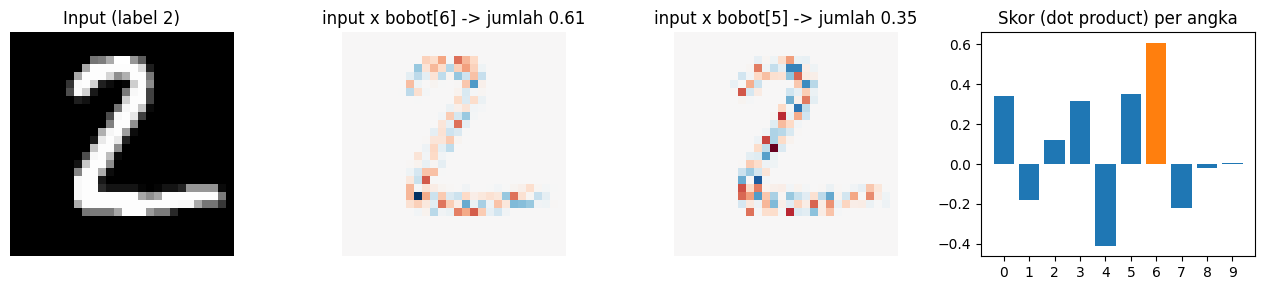

In [17]:
x = test_images[1]
scores = x.dot(W)
best = scores.argmax()
other = np.argsort(scores)[-2]

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
axes[0].imshow(x.reshape(28, 28), cmap='gray'); axes[0].set_title(f'Input (label {y_test[1]})')
for ax, d in zip(axes[1:3], [best, other]):
    prod = (x * W[:, d]).reshape(28, 28)
    lim = np.abs(prod).max()
    ax.imshow(prod, cmap='RdBu_r', vmin=-lim, vmax=lim)
    ax.set_title(f'input x bobot[{d}] -> jumlah {scores[d]:.2f}')
for ax in axes[:3]: ax.axis('off')
axes[3].bar(range(10), scores, color=['C1' if i == best else 'C0' for i in range(10)])
axes[3].set_xticks(range(10)); axes[3].set_title('Skor (dot product) per angka')
plt.tight_layout(); plt.show()

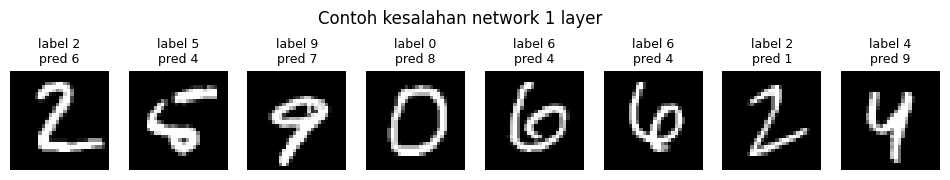

In [18]:
# Contoh gambar yang salah diklasifikasi
wrong = np.where(pred_test != y_test)[0][:8]
fig, axes = plt.subplots(1, 8, figsize=(12, 1.9))
for ax, i in zip(axes, wrong):
    ax.imshow(x_test[i], cmap='gray'); ax.axis('off')
    ax.set_title(f'label {y_test[i]}\npred {pred_test[i]}', fontsize=9)
plt.suptitle('Contoh kesalahan network 1 layer', y=1.08)
plt.show()

Network satu layer ini hanya bisa membandingkan gambar dengan **satu template per angka**. Angka yang ditulis dengan gaya berbeda (miring, tebal, terputus) sulit dikenali — keterbatasan yang akan diatasi dengan **hidden layer** (Bab 6) dan arsitektur yang lebih baik (Bab 8–10).

## Latihan

1. Latih network multiple inputs pada keempat pertandingan tetapi **bekukan bobot `wlrec`**. Apakah error tetap bisa turun?
2. Pada MNIST, berapa akurasi test jika hanya memakai **100** gambar training? Bandingkan dengan 1000.

### Contoh solusi

In [19]:
# Latihan 1
w = np.zeros(4)
for _ in range(200):
    for x_, t in zip(X_norm, y):
        delta = x_.dot(w) - t
        wd = delta * x_
        wd[1] = 0                      # bekukan wlrec
        w -= 0.05 * wd
print('Bobot (wlrec beku):', w.round(3), '| total error:', round(((X_norm.dot(w) - y) ** 2).sum(), 4))

# Latihan 2
def train_mnist_1layer(n, epochs=30):
    np.random.seed(1)
    W_ = 0.02 * np.random.random((784, 10)) - 0.01
    imgs, labs = x_train[:n].reshape(n, 784) / 255, np.eye(10)[y_train[:n]]
    for _ in range(epochs):
        for x_, t in zip(imgs, labs):
            W_ -= 0.005 * np.outer(x_, x_.dot(W_) - t)
    return (test_images.dot(W_).argmax(1) == y_test).mean()

print('Test acc dengan  100 gambar:', train_mnist_1layer(100))
print('Test acc dengan 1000 gambar:', train_mnist_1layer(1000))

Bobot (wlrec beku): [-0.115  0.     0.341  0.752] | total error: 0.0601
Test acc dengan  100 gambar: 0.6105


Test acc dengan 1000 gambar: 0.7448


## Rangkuman Bab 5

- Gradient descent **tergeneralisasi** ke banyak bobot: setiap bobot di-update dengan `delta_output × input_bobot`.
- **Multiple inputs**: semua bobot berbagi satu `delta`; input besar → kurva error curam → update besar, sehingga **normalisasi input** penting.
- **Freezing** satu bobot menunjukkan bahwa error ditentukan **bersama** oleh semua bobot; kurva error bobot yang beku ikut bergeser, dan network berhenti belajar saat error = 0.
- **Multiple outputs**: setiap output punya `delta` sendiri. **Multiple inputs & outputs**: `weight_deltas = outer(delta, input)`.
- Pada MNIST (784 → 10), network satu layer mencapai ±75% akurasi test; bobotnya bisa divisualisasikan sebagai **template** setiap angka.
- Prediksi adalah **dot product (kemiripan)** antara input dan template tersebut — keterbatasannya mendorong kebutuhan akan network yang lebih dalam.